In [ ]:
import os
import keras
from keras.utils import to_categorical
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
seed = 0
np.random.seed(seed)
import tensorflow as tf
tf.random.set_seed(seed)

2026-05-05 12:06:58.998857: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777975619.019086  177084 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777975619.024870  177084 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-05 12:06:59.049835: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
from hgq.utils.sugar import Dataset

X_train_val = np.load('X_train_val.npy')
X_test = np.load('X_test.npy')
y_train_val = np.load('y_train_val.npy')
y_test = np.load('y_test.npy')
classes = np.load('classes.npy', allow_pickle=True)


dataset_train = Dataset(X_train_val, y_train_val, batch_size=33200, device='gpu:0')
dataset_test = Dataset(X_test, y_test, batch_size=33200, device='gpu:0')


I0000 00:00:1777975623.112885  177084 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
from keras.models import Sequential
from keras.optimizers import Adam
from keras.losses import SparseCategoricalCrossentropy
from hgq.config import QuantizerConfig, QuantizerConfigScope
from hgq.layers import QDense, QSoftmax
from hgq.utils.sugar import FreeEBOPs, PBar


In [4]:
from hgq.constraints import MinMax
from hgq.config import LayerConfigScope, QuantizerConfigScope

scope0 = QuantizerConfigScope(
    place=('weight','bias'),
    default_q_type='kbi',
    overflow_mode='SAT_SYM',
    heterogeneous_axis=None,
    homogeneous_axis=(),
    trainable=True
)
scope1 = QuantizerConfigScope(
    place='datalane', 
    default_q_type='kif', 
    f0=8, i0=4, k0=0,
    fc=MinMax(2, 10), ic=MinMax(2, 6),
    heterogeneous_axis=(),
    homogeneous_axis=None, 
    trainable=True
)

In [5]:
def build_model(beta0=1e-5):
    with scope0, scope1:
        
        inputs = keras.Input(shape=(16,))

        x = QDense(64, beta0=beta0, activation='relu', name='dense_0')(inputs)
        x = QDense(32, beta0=beta0, activation='relu', name='dense_1')(x)
        x = QDense(32, beta0=beta0, activation='relu', name='dense_2')(x)
        
        outputs = QDense(5, beta0=beta0, name='dense_3')(x)
        
        model = keras.Model(inputs=inputs, outputs=outputs)

    return model

model = build_model(beta0=1e-5)
loss = keras.losses.CategoricalCrossentropy(from_logits=True)
opt = keras.optimizers.Adam(learning_rate=5e-3)

model.compile(opt, loss, metrics=['accuracy'], jit_compile=True, steps_per_execution=4)

In [6]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_0 (QDense)                │ (None, 64)             │         4,358 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (QDense)                │ (None, 32)             │         8,326 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (QDense)                │ (None, 32)             │         4,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (QDense)                │ (None, 5)              │           666 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,580 (55.80 KB)

 Trainable params: 13,171 (51.45 KB)

 Non-trainable params: 4,409 (4.35 KB)

In [9]:
import keras
import numpy as np
from math import cos, pi
from hgq.utils.sugar import BetaScheduler, Dataset, FreeEBOPs, ParetoFront, PBar, PieceWiseSchedule, EarlyStoppingWithEbopsThres
from keras.callbacks import LearningRateScheduler, CSVLogger

OUTPUT_PATH = 'model_outputs'

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)
    print(f"Created new folder: {OUTPUT_PATH}")

def cosine_decay_restarts_schedule(
    initial_lr, first_decay_steps, m_mul, alpha
):
    def schedule(step):
        cycle = step // first_decay_steps
        x = (step % first_decay_steps) / first_decay_steps
        lr = alpha + 0.5 * (initial_lr * (m_mul ** cycle) - alpha) * (1 + cos(pi * x))
        return lr
    return schedule
def warmup_cosine_schedule(
    initial_lr,
    warmup_steps,
    first_decay_steps,
    m_mul=0.9,
    alpha=1e-5
):
    cosine = cosine_decay_restarts_schedule(
        initial_lr,
        first_decay_steps,
        m_mul=m_mul,
        alpha=alpha
    )

    def schedule(step):
        # Warmup phase
        if step < warmup_steps:
            return initial_lr * (0.1 + 0.9 * step / warmup_steps)

        # Cosine phase
        return cosine(step - warmup_steps)

    return schedule

#pbar = PBar('loss: {loss:.2f}/{val_loss:.2f} - acc: {accuracy:.4f}/{val_accuracy:.4f} - lr: {learning_rate:.2e} - beta: {beta:.1e}')
pbar = PBar('loss: {loss:.2f}/{val_loss:.2f} - acc: {accuracy:.4f}/{val_accuracy:.4f}')

ebops = FreeEBOPs()
pareto = ParetoFront(
        OUTPUT_PATH,
        ['val_accuracy', 'ebops'],
        [1, -1],
        fname_format='epoch={epoch}-val_acc={val_accuracy:.3f}-ebops={ebops}-val_loss={val_loss:.3f}.keras',
    )

estop = EarlyStoppingWithEbopsThres(ebops_threshold=2000, monitor='val_accuracy', patience=30, restore_best_weights=True)
beta_sched = BetaScheduler(
    PieceWiseSchedule([
        (0,    1e-7, 'constant'),
        (50,  1e-7, 'log'),
        (500,   1e-6, 'log'),
        (1500, 1e-5, 'log'),
        (3000, 1e-4, 'constant'),
    ])
)
lr_sched = LearningRateScheduler(
    warmup_cosine_schedule(
        initial_lr=1e-3,
        warmup_steps=50,
        first_decay_steps=250,
        m_mul=0.9,
        alpha=1e-5
    )
)

csv_logger = CSVLogger('MNIST_HGQ_DynamicTraining_log.csv', append=True, separator=';')

callbacks = [ebops, pbar, pareto, estop, csv_logger]
#lr_sched, beta_sched,

In [ ]:
model.fit(dataset_train, validation_data=dataset_test, epochs=3000, verbose=0, callbacks=callbacks)

KeyboardInterrupt: 

In [28]:
score = model.evaluate(dataset_test)
model.save('model_HGQ/model_HGQ.keras')

print("Test loss:", score[0])
print("Test accuracy:", score[1])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7620 - loss: 0.6617
Test loss: 0.6617485880851746
Test accuracy: 0.7620060443878174


In [6]:
from tensorflow.keras.models import load_model

model = load_model('model_HGQ/model_HGQ.keras')


score = model.evaluate(dataset_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

I0000 00:00:1774865957.379184    1824 service.cc:148] XLA service 0x7d0c08005740 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774865957.379619    1824 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-03-30 12:19:17.463240: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774865957.657483    1824 cuda_dnn.cc:529] Loaded cuDNN version 91002


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 670ms/step - accuracy: 0.7471 - loss: 0.7373
Test loss: 0.7373369932174683
Test accuracy: 0.7471325397491455


I0000 00:00:1774865959.253693    1824 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [29]:
y_hgq = model.predict(X_test)

hgq_size = y_hgq.size
zero_count = np.count_nonzero(y_hgq == 0)
print(zero_count)


5188/5188 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step
722


5188/5188 ━━━━━━━━━━━━━━━━━━━━ 5s 996us/step
Accuracy: 0.7620060240963855


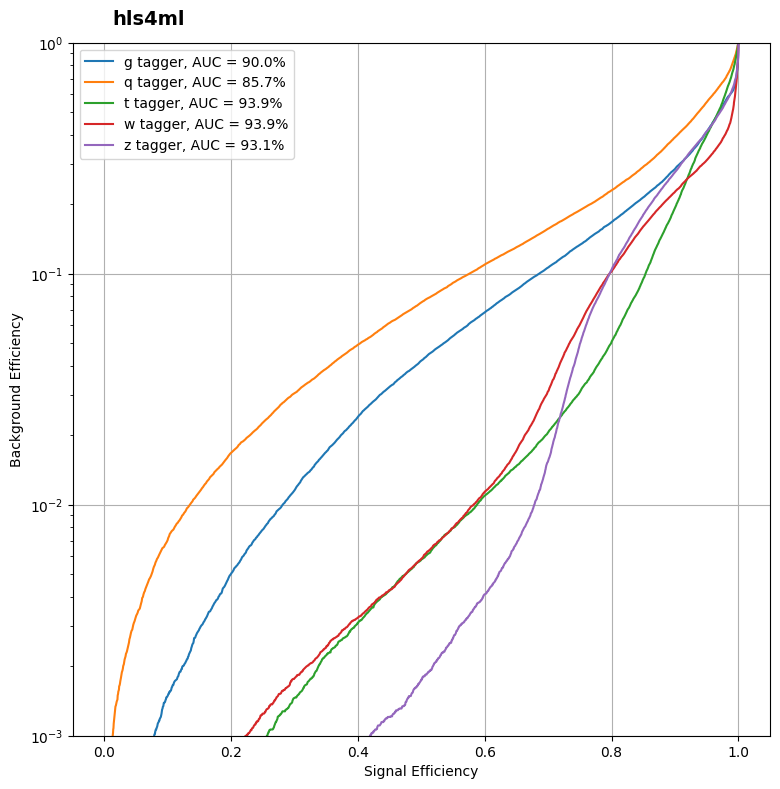

In [30]:
import plotting
from sklearn.metrics import accuracy_score

y_hgq = model.predict(X_test)
print("Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hgq, axis=1))))
plt.figure(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_hgq, classes)


In [31]:
from hgq.utils import trace_minmax
import hls4ml

# Trace the required number of integer bits for activations
# This step is only necessary when using WRAP overflow mode (recommended) for data.
trace_minmax(model, X_test, verbose=True)

config = hls4ml.utils.config_from_keras_model(model, granularity='name', backend='Vitis')

config['Model']['ReuseFactor'] = 1
config['Model']['Strategy'] = 'Distributed Arithmetic'
#config['LayerName']['dense_1']['Strategy'] = 'Resource'

print("-----------------------------------")
print("Configuration")
plotting.print_dict(config)
print("-----------------------------------")
hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vitis', output_dir='model_HGQ/hls4ml_prj', part='xcu250-figd2104-2L-e'
)

hls_model.compile()
X_test = np.ascontiguousarray(X_test)
y_hls = hls_model.predict(X_test)



dense_0: 43257
dense_1: 74004
dense_2: 30974
dense_3: 5469
Total: 153704
-----------------------------------
Configuration
Model
  Precision
    default:         fixed<16,6>
  ReuseFactor:       1
  Strategy:          Distributed Arithmetic
  BramFactor:        1000000000
  TraceOutput:       False
LayerName
  input_layer_4
    Trace:           False
    Precision
      result:        auto
  dense_0_iq
    Trace:           False
    Precision
      result:        auto
  dense_0
    Trace:           False
    Precision
      result:        auto
      weight:        auto
      bias:          auto
      accum:         auto
    ReuseFactor:     1
  dense_0_relu
    Trace:           False
    Precision
      result:        auto
      table:         fixed<18,8,TRN,WRAP,0>
    ReuseFactor:     1
    TableSize:       1024
  dense_1_iq
    Trace:           False
    Precision
      result:        auto
  dense_1
    Trace:           False
    Precision
      result:        auto
      weight:    

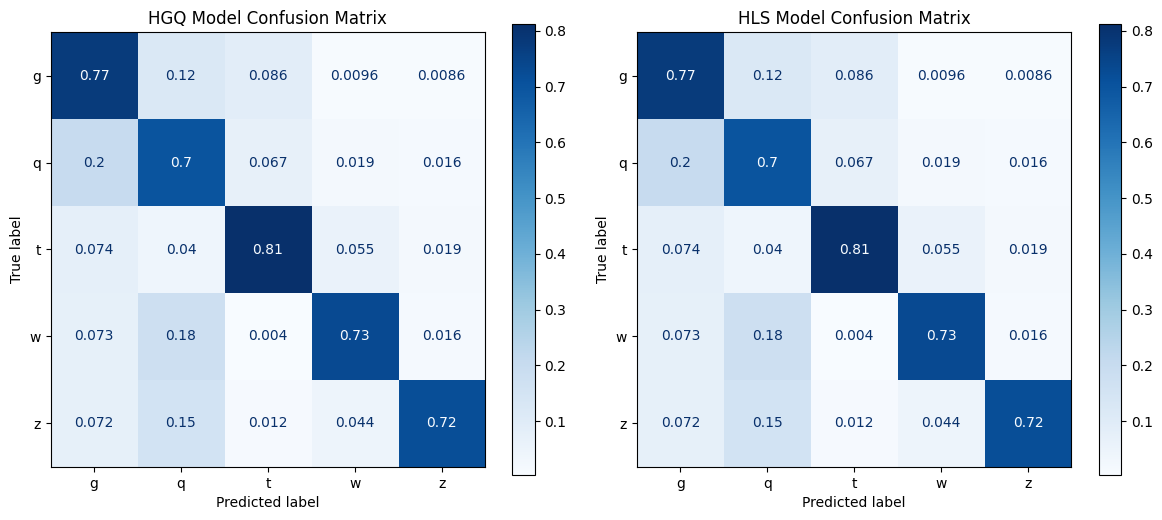

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_hgq_pred = np.argmax(y_hgq, axis=1)
y_hgq_true = np.argmax(y_test, axis=1)
y_hls_pred = np.argmax(y_hls, axis=1)
y_hls_true = np.argmax(y_test, axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
cm_hgq = confusion_matrix(y_hgq_true, y_hgq_pred, normalize='true')
cm_hls = confusion_matrix(y_hls_true, y_hls_pred, normalize='true')

# Plot it
disp_hgq = ConfusionMatrixDisplay(confusion_matrix=cm_hgq, display_labels=classes)
disp_hgq.plot(ax=ax[0],cmap=plt.cm.Blues)
ax[0].set_title('HGQ Model Confusion Matrix')

disp_hls = ConfusionMatrixDisplay(confusion_matrix=cm_hls, display_labels=classes)
disp_hls.plot(ax=ax[1],cmap=plt.cm.Blues)
ax[1].set_title('HLS Model Confusion Matrix')

plt.tight_layout()
plt.show()

In [32]:
# 2. Calculate Mean Squared Error (MSE) between the two
# This tells you how much the "Hardware Math" deviates from "Python Math"
diff = np.mean(np.square(y_hgq - y_hls))
print(f"Quantization Error (MSE): {diff}")

Quantization Error (MSE): 1.4545486634036144e-07


In [33]:
from tensorflow.keras.models import load_model
model_baseline = load_model('model_baseline/KERAS_check_best_model.h5')

adam = Adam(learning_rate=0.0001)
model_baseline.compile(optimizer=adam, loss=['categorical_crossentropy'], metrics=['accuracy'])

# 3. Evaluate

score = model_baseline.evaluate(dataset_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

y_baseline = model_baseline.predict(np.ascontiguousarray(X_test))

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7362 - loss: 0.8109
Test loss: 0.8108834028244019
Test accuracy: 0.7362470030784607
5188/5188 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step


In [34]:
print(y_hls[:5])
print(y_hgq[:5])

[[ 1.46484375  0.79296875 -1.61328125  0.04296875 -0.14453125]
 [-0.1171875   2.64453125 -2.86328125  1.02734375  0.796875  ]
 [ 1.46875     1.59375     2.984375   -3.609375   -3.890625  ]
 [-0.1640625   0.484375    5.6875     -1.5078125  -1.8828125 ]
 [ 0.87890625  0.6640625   5.58203125 -2.81640625 -5.02734375]]
[[ 1.4648438   0.79296875 -1.6132812   0.04296875 -0.14453125]
 [-0.1171875   2.6445312  -2.8632812   1.0273438   0.796875  ]
 [ 1.46875     1.59375     2.984375   -3.609375   -3.890625  ]
 [-0.1640625   0.484375    5.6875     -1.5078125  -1.8828125 ]
 [ 0.87890625  0.6640625   5.5820312  -2.8164062  -5.0273438 ]]


Max Bit-Error: 0.210938
HGQ2  Accuracy: 0.7620060240963855
hls4ml Accuracy: 0.7620060240963855
Keras Accuracy: 0.7362469879518072


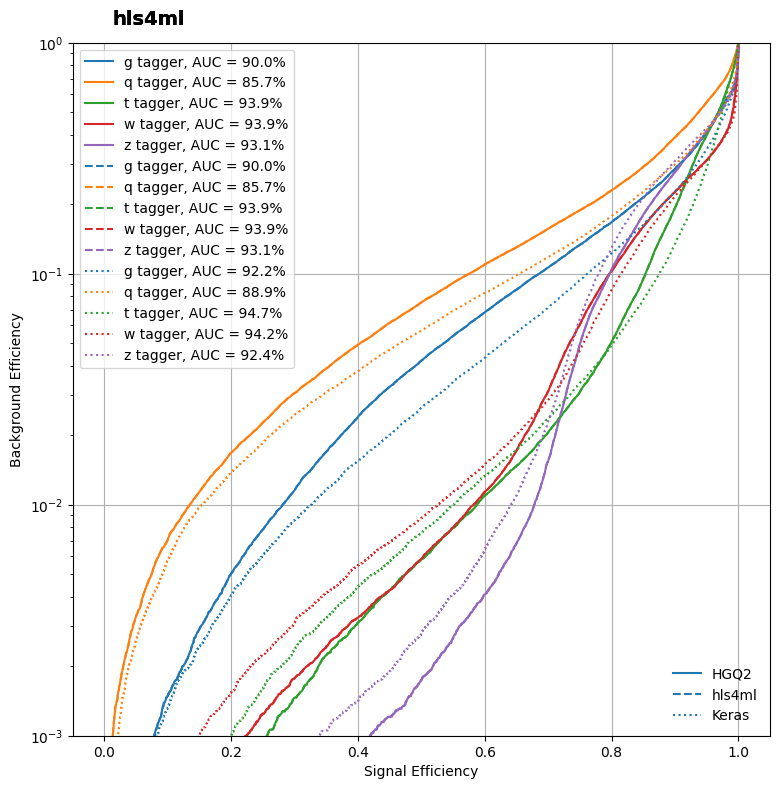

In [35]:

# check bit-accuracy by comparing the outputs of HGQ and hls4ml
max_diff = np.max(np.abs(y_hgq - y_hls))
print("Max Bit-Error: {:.6f}".format(max_diff))

print("HGQ2  Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hgq, axis=1))))
print("hls4ml Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_hls, axis=1))))
print("Keras Accuracy: {}".format(accuracy_score(np.argmax(y_test, axis=1), np.argmax(y_baseline, axis=1))))

fig, ax = plt.subplots(figsize=(9, 9))
_ = plotting.makeRoc(y_test, y_hgq, classes)
plt.gca().set_prop_cycle(None)  # reset the colors
_ = plotting.makeRoc(y_test, y_hls, classes, linestyle='--')
plt.gca().set_prop_cycle(None)
_ = plotting.makeRoc(y_test, y_baseline, classes, linestyle=':')

from matplotlib.lines import Line2D

lines = [Line2D([0], [0], ls='-'), 
         Line2D([0], [0], ls='--'),
         Line2D([0], [0], ls=':')]

from matplotlib.legend import Legend

leg = Legend(ax, lines, labels=['HGQ2', 'hls4ml', 'Keras'], loc='lower right', frameon=False)
ax.add_artist(leg)

In [36]:
import gc
import keras.backend as K
import tensorflow as tf

# 1. Clear Keras global state
K.clear_session()

# 2. Force garbage collection to reclaim memory from deleted objects
gc.collect()

# 3. (Optional) If using GPU, reset the memory
# Note: This is only available in some versions/backends
if tf.config.list_physical_devices('GPU'):
    try:
        from numba import cuda
        cuda.select_device(0)
        cuda.close()
    except:
        pass